In [1]:
import cv2
import os
import pickle
import numpy as np

Loading angry images...
  Loaded 3009 images
Loading happy images...
  Loaded 4097 images
Loading neutral images...
  Loaded 3026 images
Loading sad images...
  Loaded 3026 images
Loading surprised images...
  Loaded 2924 images

Total images: 16082
Labels distribution: {'angry': 3009, 'happy': 4097, 'neutral': 3026, 'sad': 3026, 'surprised': 2924}


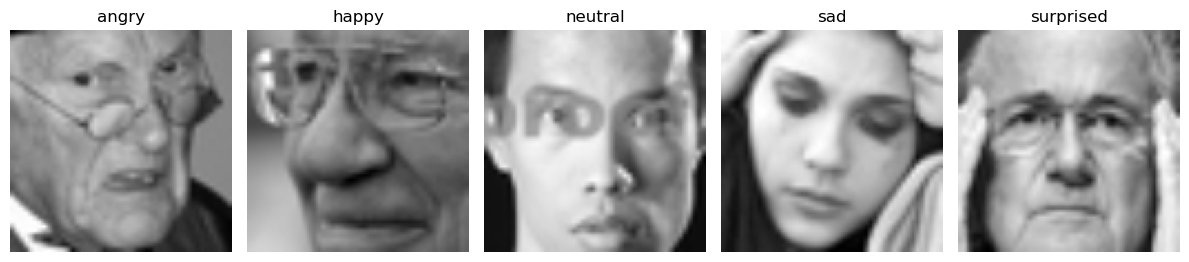


Data saved to data/images.p and data/labels.p


In [2]:
data_dir = os.path.join(os.getcwd(), 'data')
os.makedirs(data_dir, exist_ok=True)

emotions = ['angry', 'happy', 'neutral', 'sad', 'surprised']

image_data = []
labels = []

for emotion in emotions:
    emotion_dir = os.path.join(os.getcwd(), emotion)
    print(f'Loading {emotion} images...')
    count = 0
    for fname in os.listdir(emotion_dir):
        if not fname.lower().endswith('.png'):
            continue
        img_path = os.path.join(emotion_dir, fname)
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.resize(image, (100, 100))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image_data.append(image)
        labels.append(emotion)
        count += 1
    print(f'  Loaded {count} images')

image_data = np.array(image_data)
labels = np.array(labels)

print(f'\nTotal images: {len(image_data)}')
print(f'Labels distribution: {dict(zip(*np.unique(labels, return_counts=True)))}')

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
for i, emotion in enumerate(emotions):
    idx = np.where(labels == emotion)[0][0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(image_data[idx], cmap='gray')
    plt.title(emotion)
    plt.axis('off')
plt.tight_layout()
plt.show()

with open(os.path.join(data_dir, 'images.p'), 'wb') as f:
    pickle.dump(image_data, f)

with open(os.path.join(data_dir, 'labels.p'), 'wb') as f:
    pickle.dump(labels, f)

print('\nData saved to data/images.p and data/labels.p')